# Pairwise Correlation of Multivariate Time Series

`multivariate_correlation` builds an $N \times N$ matrix that compares every pair of channels in a multivariate series. The input convention is **one channel per row**:

$$
X \in \mathbb{R}^{N \times L}, \qquad N \ge 2,\; L \ge 2
$$

that is `shape = [num_samples, seq_length]`. This is the transpose of the coupling-pipeline layout `(T, Q)`: if you have `(T, Q)`, pass `series.T`.

Six measures are available (`AVAILABLE_CORRELATION_MEASURES`):

| Name | What it compares | Matrix type |
| --- | --- | --- |
| `pearson` | Linear co-movement of the raw values | correlation in $[-1, 1]$ |
| `spearman` | Monotonic (rank) co-movement | correlation in $[-1, 1]$ |
| `autocorrelation` | Similarity of ACF shapes | correlation of ACF vectors |
| `power_spectrum` | Similarity of Welch PSDs | correlation of spectra |
| `distribution` | Similarity of value histograms | correlation of shared-bin histograms |
| `wasserstein` | 1-D / windowed Wasserstein distance | **distance** (diagonal 0; smaller = closer) |

Pass a single name to get one matrix, or a space-separated string / list to get a `dict`. `plot_correlation` draws the same matrices as heatmaps. Aliases such as `corr`, `acf`, `psd`, `wdist` are accepted.

The examples below use a shared latent, a nonlinear monotone pair, two sines that share a frequency but not a phase, mismatched distributions, and a bundled ETT slice.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    multivariate_correlation,
    plot_correlation,
    plot_multivariate_time_series,
    load_multivariate,
)
from s2generator.utils._multivariate_correlation import (
    AVAILABLE_CORRELATION_MEASURES,
)

print("measures:", AVAILABLE_CORRELATION_MEASURES)
rng = np.random.RandomState(0)

measures: ('pearson', 'spearman', 'autocorrelation', 'power_spectrum', 'distribution', 'wasserstein')


## 1. Shared latent: Pearson picks up linear mixing

Channels 0 and 1 are noisy observations of the same random-walk latent; channel 2 is independent Gaussian noise. Pearson (and Spearman) between 0 and 1 should be high; both should be near 0 against channel 2.


shape [N, L] = (3, 256)


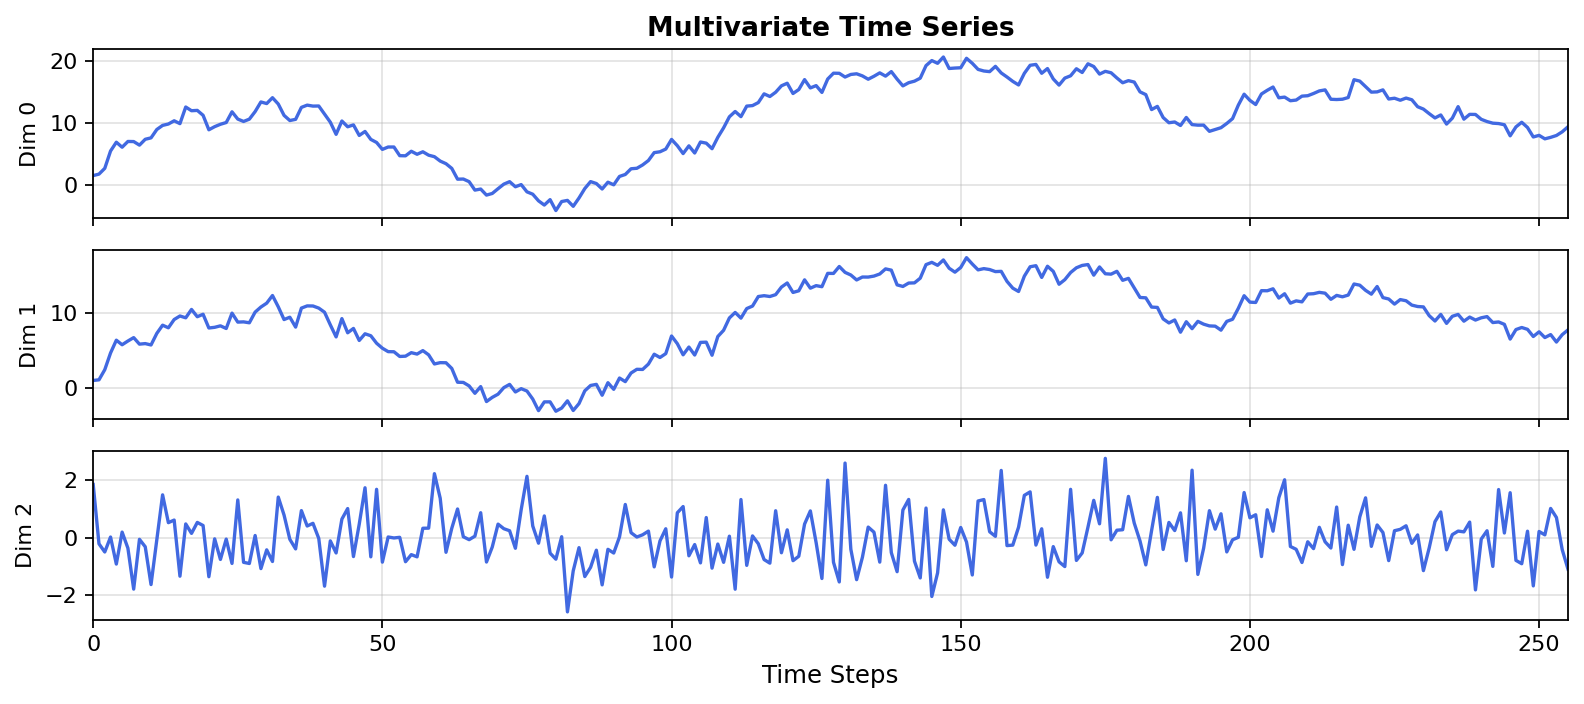

Pearson matrix:
 [[1.    0.996 0.086]
 [0.996 1.    0.086]
 [0.086 0.086 1.   ]]


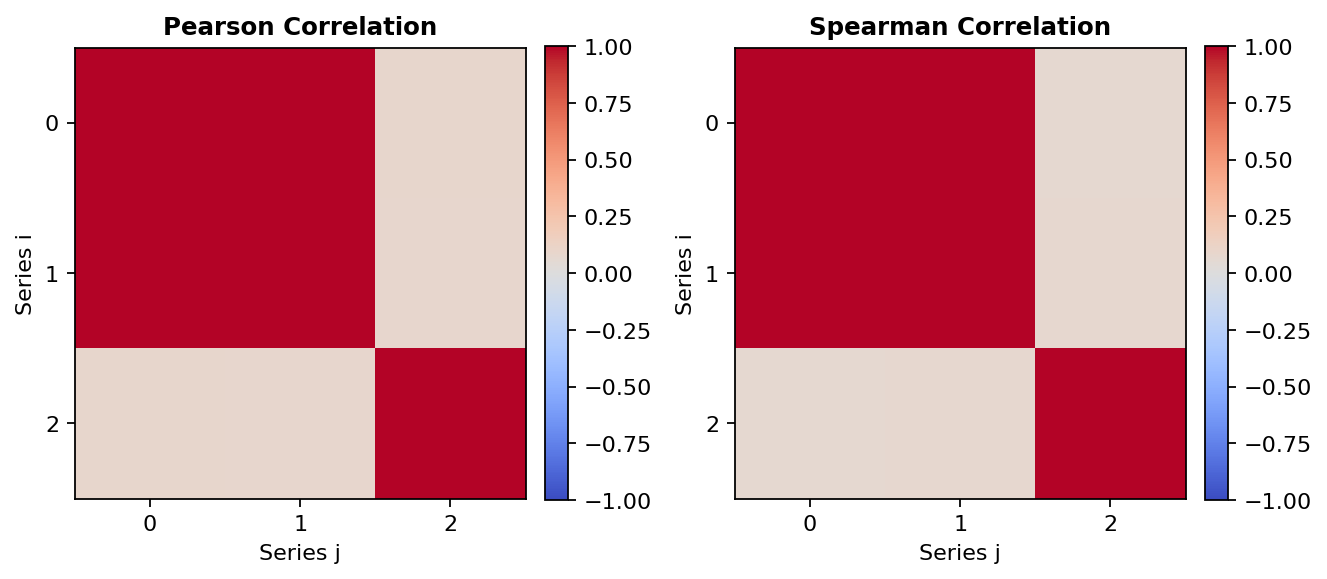

In [2]:
T = 256
latent = rng.normal(0.0, 1.0, T).cumsum()
shared = np.vstack(
    [
        latent + 0.25 * rng.normal(0.0, 1.0, T),
        0.85 * latent + 0.40 * rng.normal(0.0, 1.0, T),
        rng.normal(0.0, 1.0, T),
    ]
)
print("shape [N, L] =", shared.shape)

plot_multivariate_time_series(shared, figsize=(10, 4.5))
plt.show()

R = multivariate_correlation(shared, measure="pearson")
print("Pearson matrix:\n", np.round(R, 3))
plot_correlation(shared, measure="pearson spearman")
plt.show()

## 2. Nonlinear but monotone: Spearman vs Pearson

Let $y = x^3$ plus a little noise. The relationship is strictly increasing, so **Spearman** stays close to 1, while **Pearson** understates it because the map is nonlinear. An independent channel is the control.


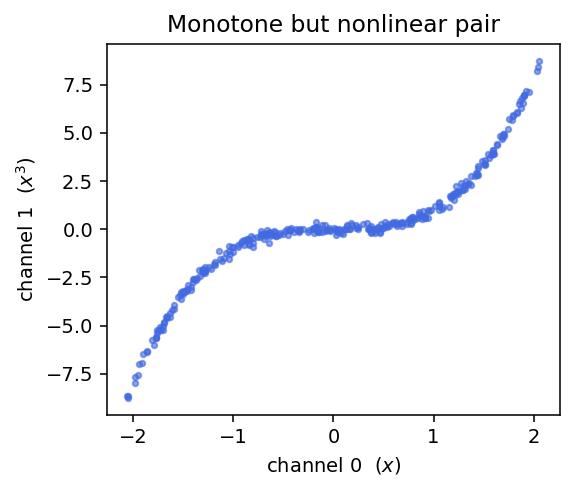

Pearson(0, 1)  = 0.915
Spearman(0, 1) = 0.984


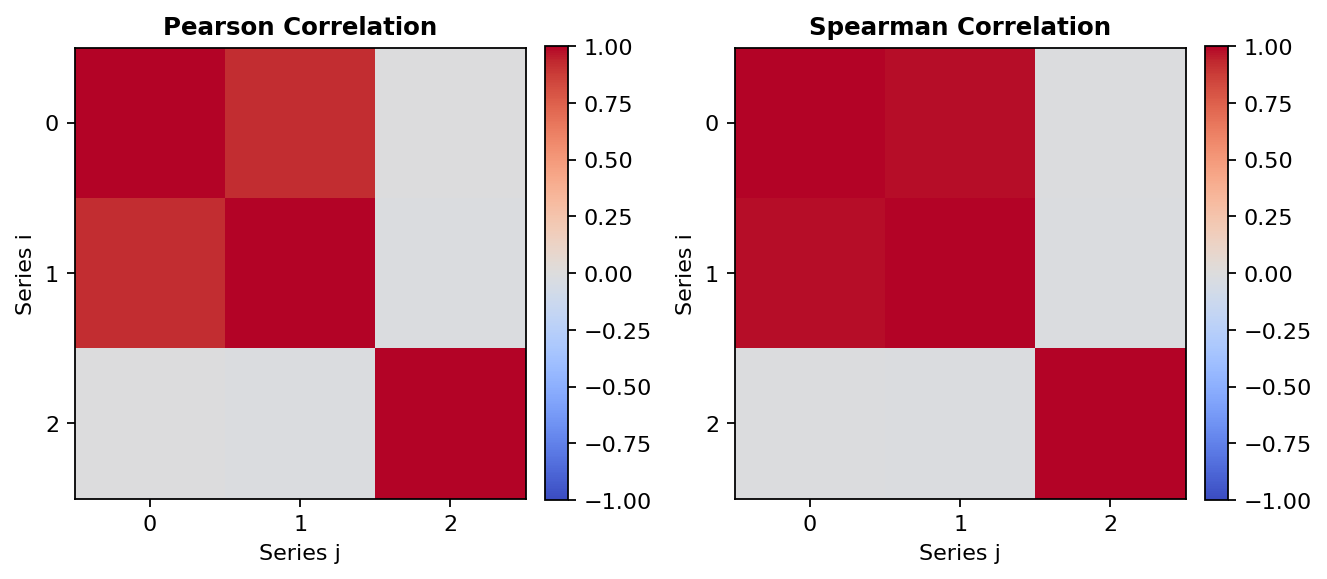

In [3]:
t = np.linspace(-2.0, 2.0, 320)
x = t + 0.08 * rng.normal(0.0, 1.0, t.size)
y = x**3 + 0.15 * rng.normal(0.0, 1.0, t.size)
z = rng.normal(0.0, 1.0, t.size)
cubic = np.vstack([x, y, z])

fig, ax = plt.subplots(figsize=(4.2, 3.6), dpi=140)
ax.scatter(x, y, s=8, alpha=0.6, color="royalblue")
ax.set_xlabel("channel 0  ($x$)")
ax.set_ylabel("channel 1  ($x^3$)")
ax.set_title("Monotone but nonlinear pair")
fig.tight_layout()
plt.show()

mats = multivariate_correlation(cubic, measure=["pearson", "spearman"])
print("Pearson(0, 1)  =", round(float(mats["pearson"][0, 1]), 3))
print("Spearman(0, 1) =", round(float(mats["spearman"][0, 1]), 3))
plot_correlation(cubic, measure="pearson spearman")
plt.show()

## 3. Same frequency, different phase: ACF and PSD

A sine and a cosine of the **same** period are orthogonal, so Pearson is near 0. Their power spectra (and ACFs) are almost identical. A third channel at a different frequency, and a noisy copy of the first sine, complete the set.

- `power_spectrum` / `autocorrelation`: channels 0, 1, 3 cluster together.
- `pearson`: 0 and 1 look unrelated; 0 and 3 remain correlated.


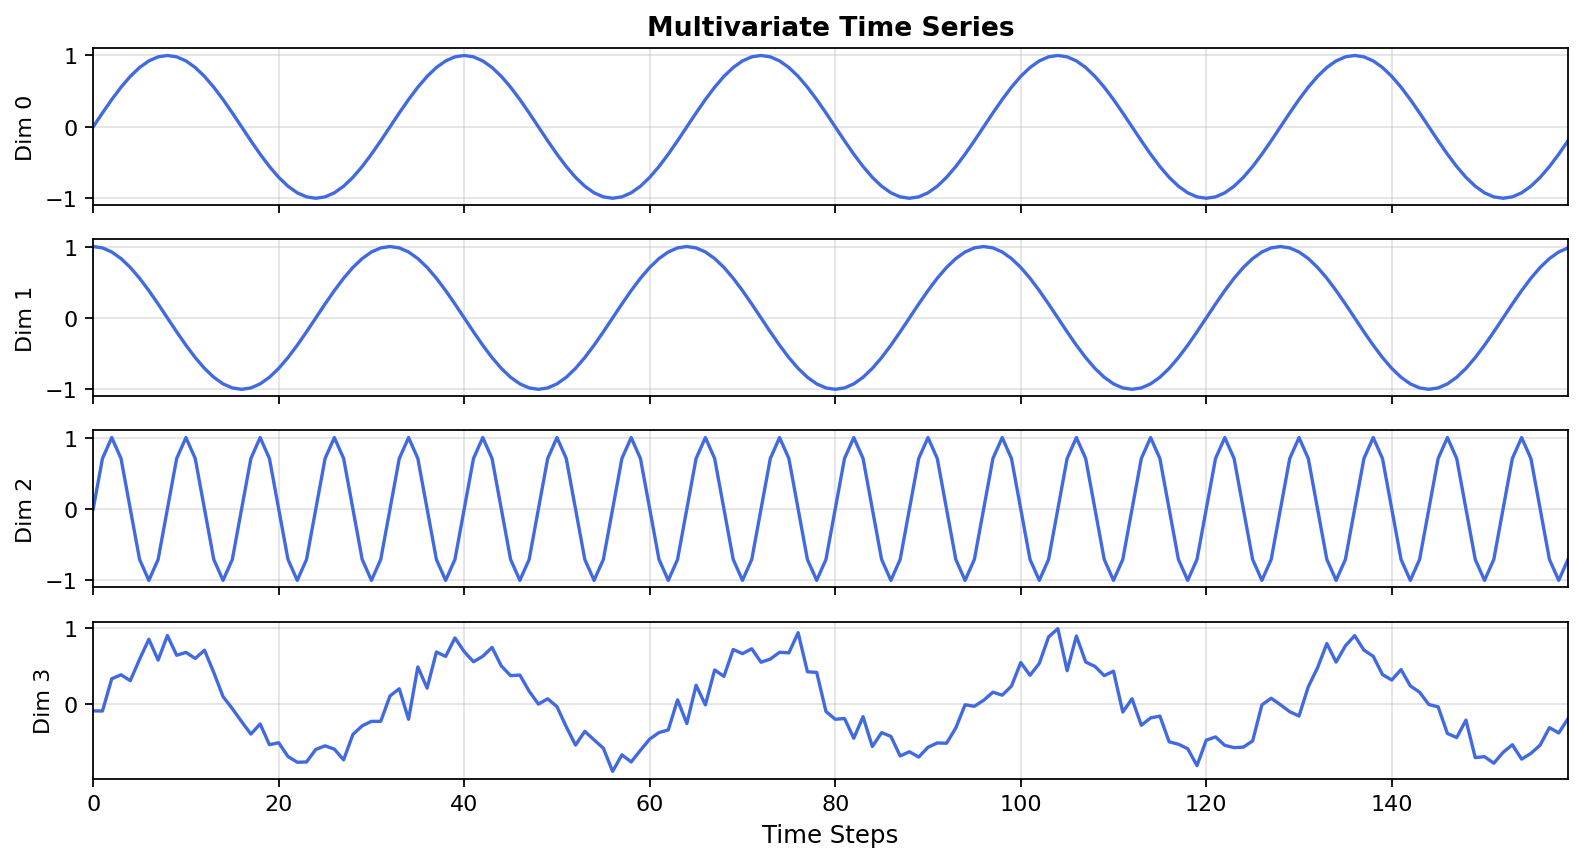

Pearson(0, 1) ≈ -0.0   (phase shift ~ 90 deg)


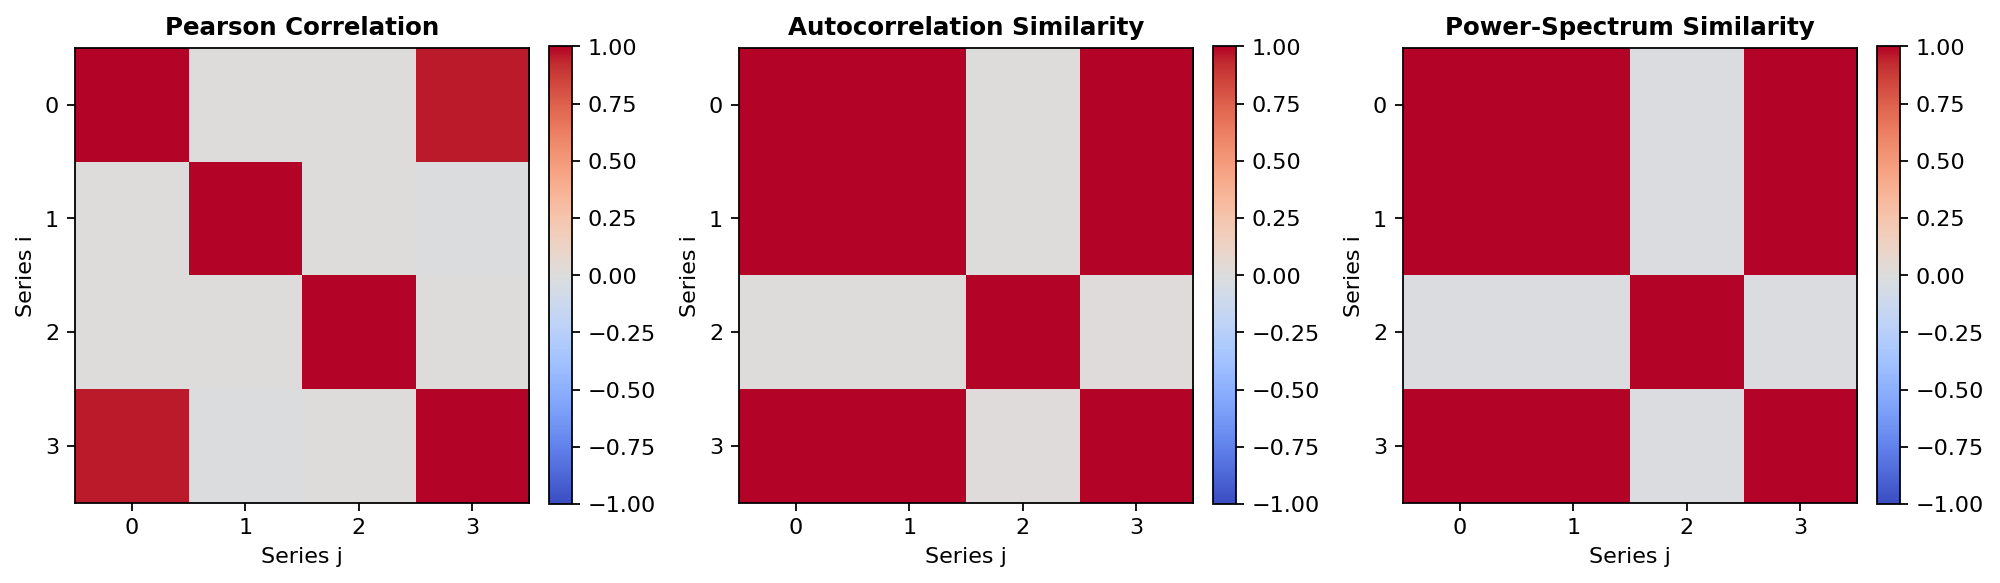

In [4]:
n = 512
tt = np.arange(n, dtype=float)
sines = np.vstack(
    [
        np.sin(2 * np.pi * tt / 32.0),
        np.cos(2 * np.pi * tt / 32.0),
        np.sin(2 * np.pi * tt / 8.0),
        0.7 * np.sin(2 * np.pi * tt / 32.0) + 0.15 * rng.normal(0.0, 1.0, n),
    ]
)

plot_multivariate_time_series(sines[:, :160], figsize=(10, 5.5))
plt.show()

print(
    "Pearson(0, 1) ≈",
    round(float(multivariate_correlation(sines, "pearson")[0, 1]), 3),
    "  (phase shift ~ 90 deg)",
)
plot_correlation(
    sines,
    measure="pearson autocorrelation power_spectrum",
    nlags=40,
)
plt.show()

## 4. Value histograms vs Wasserstein distance

Four i.i.d. draws: two $\mathcal{N}(0,1)$, one $\mathcal{N}(3,1)$, and a uniform on $[-1, 1]$. There is **no temporal dependence**, so Pearson / ACF / PSD are uninformative.

- `distribution` correlates shared-bin histograms: the two standard normals match; the shifted Gaussian and the uniform do not.
- `wasserstein` is a **distance** (viridis heatmap). The two $\mathcal{N}(0,1)$ channels are close; $\mathcal{N}(3,1)$ is far from both.


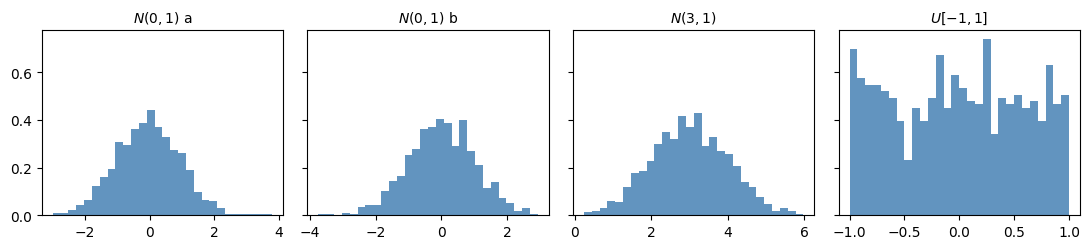

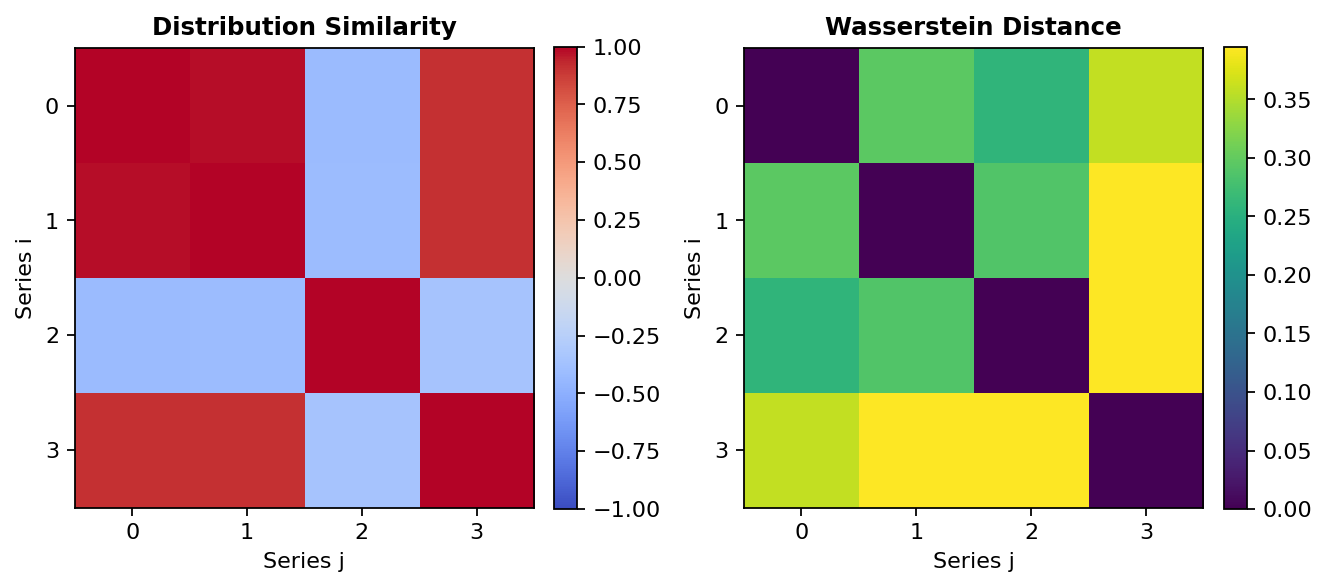

Wasserstein distances:
 [[0.    0.295 0.258 0.358]
 [0.295 0.    0.288 0.395]
 [0.258 0.288 0.    0.395]
 [0.358 0.395 0.395 0.   ]]


In [5]:
n = 1024
iid = np.vstack(
    [
        rng.normal(0.0, 1.0, n),
        rng.normal(0.0, 1.0, n),
        rng.normal(3.0, 1.0, n),
        rng.uniform(-1.0, 1.0, n),
    ]
)

fig, axes = plt.subplots(1, 4, figsize=(11, 2.6), sharey=True)
titles = [r"$N(0,1)$ a", r"$N(0,1)$ b", r"$N(3,1)$", r"$U[-1,1]$"]
for ax, row, title in zip(axes, iid, titles):
    ax.hist(row, bins=28, density=True, color="steelblue", alpha=0.85)
    ax.set_title(title, fontsize=10)
fig.tight_layout()
plt.show()

plot_correlation(iid, measure="distribution wasserstein", bins=32)
plt.show()

W = multivariate_correlation(iid, measure="wasserstein")
print("Wasserstein distances:\n", np.round(W, 3))

## 5. Bundled ETTh1 channels

`load_multivariate("ETTh1")` returns a DataFrame `(T, Q+date)`. Drop the date column and transpose so each numeric sensor is a row. The oil-temperature related channels (and the load / oil-temperature groups on ETT) typically show a block of high Pearson correlation; `wasserstein` then ranks how far the **distributions** sit from each other.


ETTh1 channels: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
array shape [N, L] = (7, 1024)


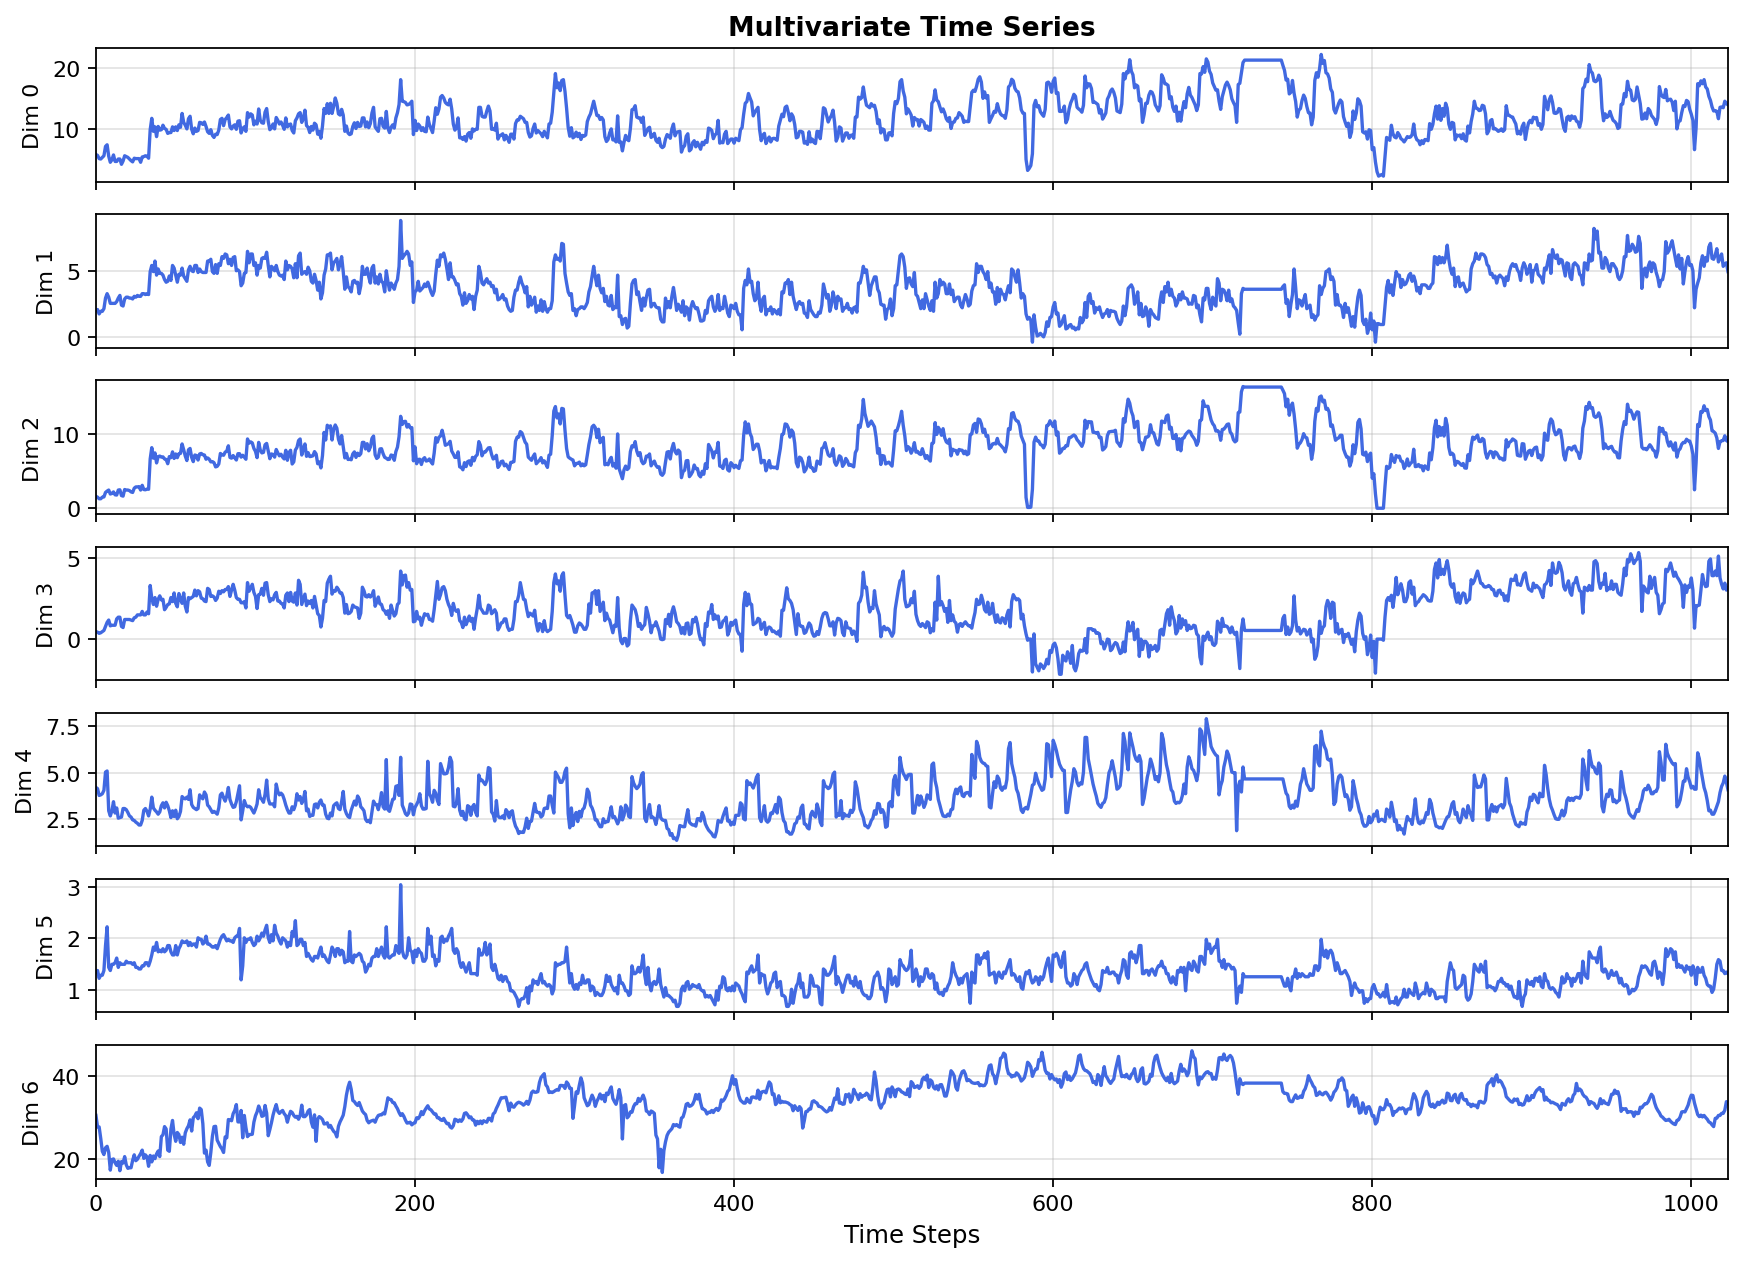

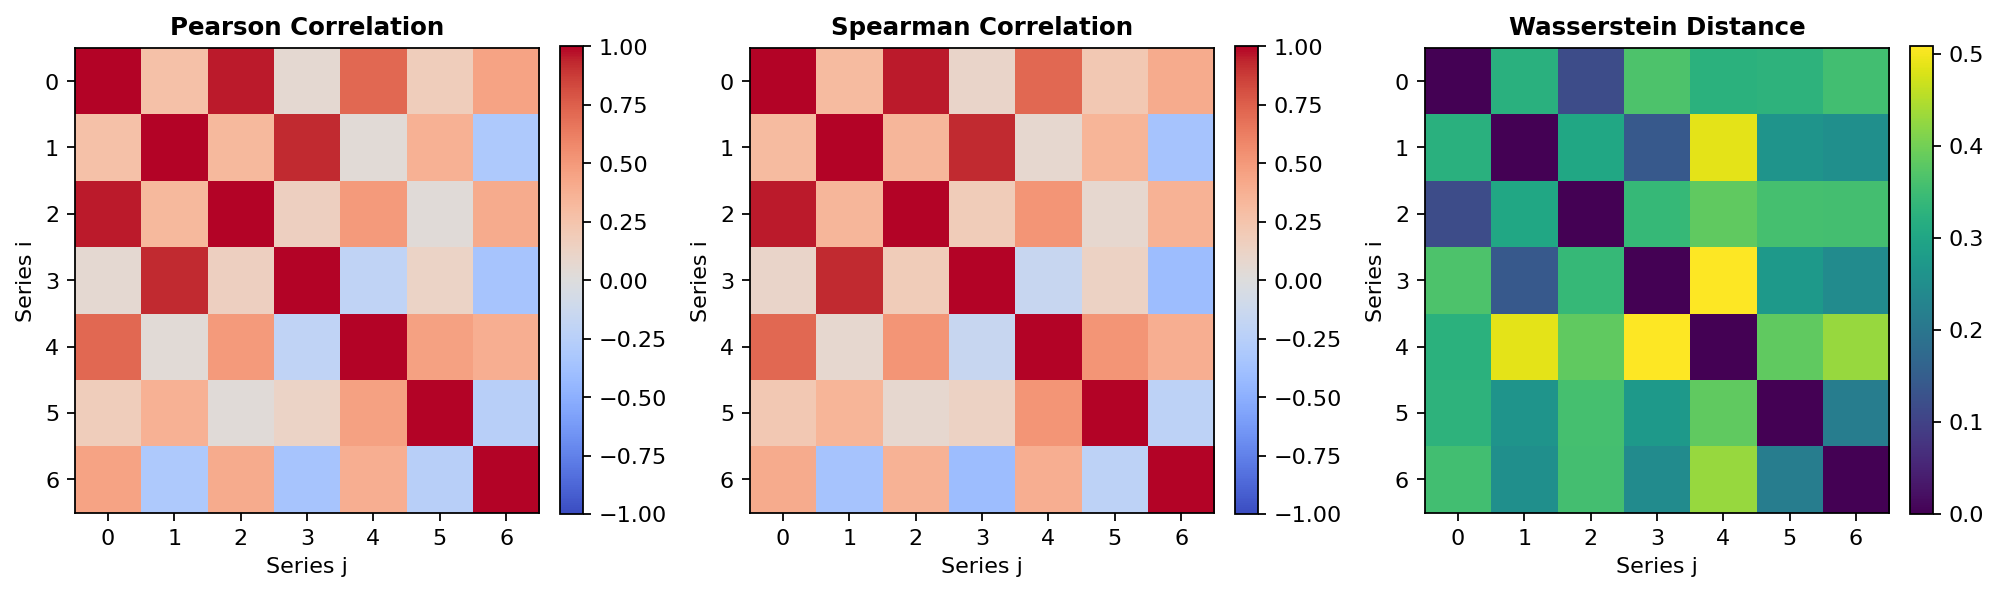

In [6]:
frame = load_multivariate("ETTh1")
numeric = frame.select_dtypes(include=[np.number])
ett = numeric.to_numpy(dtype=np.float64).T  # [Q, T]
ett = ett[:, :1024]
print("ETTh1 channels:", list(numeric.columns))
print("array shape [N, L] =", ett.shape)

plot_multivariate_time_series(ett, figsize=(11, 8))
plt.show()

plot_correlation(ett, measure="pearson spearman wasserstein")
plt.show()

## 6. All six measures on one figure

`measure` can be a list or a space-separated string. Extra kwargs (`nlags`, `bins`, `mean_weight`, `covar_weight`) are forwarded to the estimators that use them. On the shared-latent series from Example 1, Pearson / Spearman light up the $(0,1)$ block; Wasserstein is the only panel that is a distance (not a signed correlation).


requesting: ['pearson', 'spearman', 'autocorrelation', 'power_spectrum', 'distribution', 'wasserstein']
pearson           shape=(3, 3)  min=0.086  max=1.000
spearman          shape=(3, 3)  min=0.069  max=1.000
autocorrelation   shape=(3, 3)  min=0.274  max=1.000
power_spectrum    shape=(3, 3)  min=0.077  max=1.000
distribution      shape=(3, 3)  min=-0.257  max=1.000
wasserstein       shape=(3, 3)  min=0.000  max=0.723


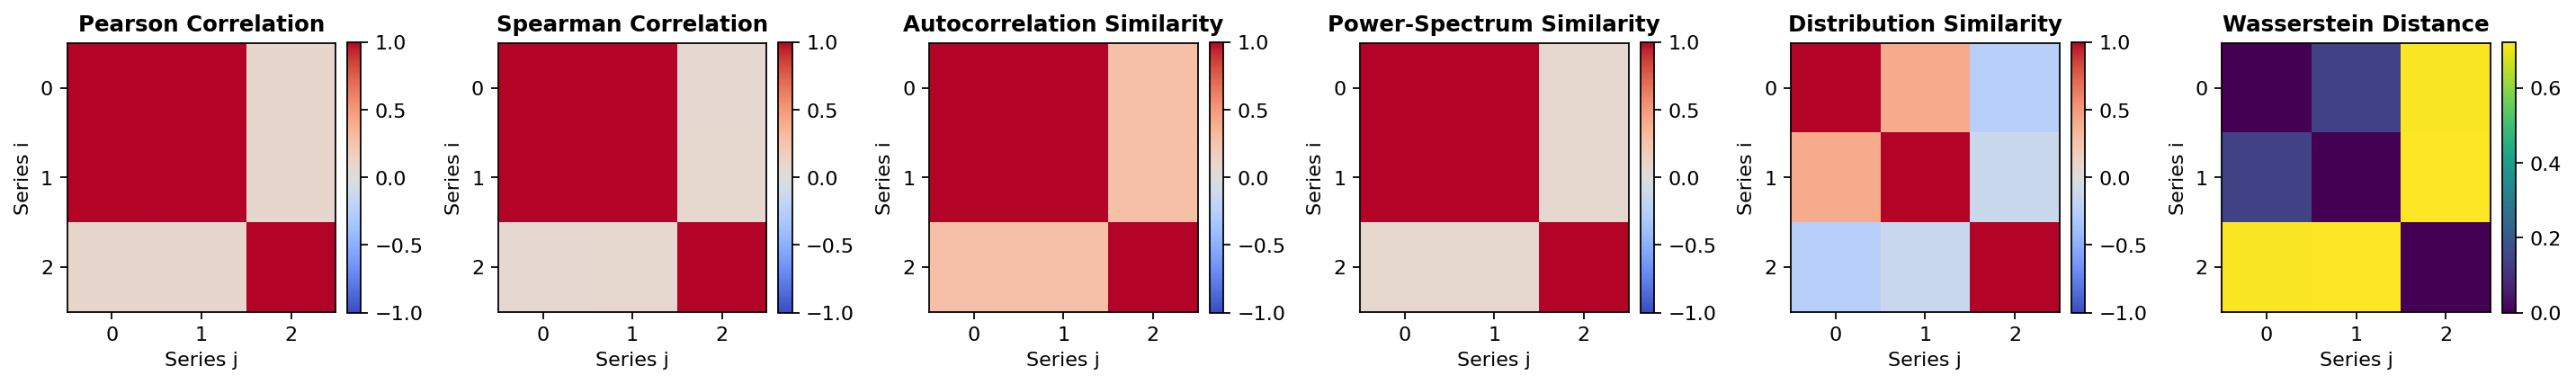

In [7]:
all_measures = list(AVAILABLE_CORRELATION_MEASURES)
print("requesting:", all_measures)

result = multivariate_correlation(
    shared,
    measure=all_measures,
    nlags=24,
    bins=24,
)
assert isinstance(result, dict)
for name, mat in result.items():
    print(f"{name:16s}  shape={mat.shape}  min={mat.min():.3f}  max={mat.max():.3f}")

plot_correlation(
    shared,
    measure="pearson spearman autocorrelation power_spectrum distribution wasserstein",
    nlags=24,
    bins=24,
    figsize=(18, 3.6),
)
plt.show()